# Introduction
From Kaggle, we got a dataset of Fake Yelp Review (MIT Licensed). We will build model to detect and identify fake reviews and also do a quick sentimental analysis. We are already given two cleaned separate training and testing datasets. No major class imablance was detected.

In [16]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, accuracy_score
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
!pip install textblob
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack
from sklearn.preprocessing import StandardScaler
import numpy as np

train_df = pd.read_csv('new_data_train.csv', on_bad_lines='skip', sep = '\t')
print(list(train_df.columns))
print(train_df.head())

# check size of the dataframe rows x columns
print(len(train_df), len(train_df.columns))

#print to check class imbalance
print(train_df.value_counts('flagged'))


train_df = train_df.dropna(subset=['reviewContent'])

#printing if rows changed
print(len(train_df)) #only 3 rows with NaN

['Unnamed: 0', 'reviewID', 'reviewerID', 'restaurantID', 'date', 'rating', 'reviewUsefulCount', 'reviewContent', 'flagged', 'name', 'location', 'yelpJoinDate', 'friendCount', 'reviewCount', 'firstCount', 'usefulCount', 'coolCount', 'funnyCount', 'complimentCount', 'tipCount', 'fanCount', 'restaurantRating', 'ReviewLength']
   Unnamed: 0                reviewID              reviewerID  \
0        6010  Z_wgGcI8_Txo87Wz7CxdrQ  cM9GIlk61Qh2thLyJyxNyA   
1        6566  NJfQb03MSstqYagt860Oaw  SVlSPBnjCzY2Bu9n8y2C5A   
2       21349  2uao3bK9iSV4fuMwuSYCiQ  5HYWhPS3ozYifieW0lWMUw   
3       10370  6mVU2JfeSbQ-5RnPm-K6eA  dgKmhiTypR34XNPrMtQyMA   
4        6011  e25NUAMnVf7-t8-vBO_drA  uB3n74XHDFUKwHxfK5lDvA   

             restaurantID       date  rating  reviewUsefulCount  \
0  N7juvW8YoFIj7sEBzVF8GQ  9/17/2010       5                  0   
1  o54U2VkQama8FI30qDkWvw  1/31/2008       5                  0   
2  1QKqtC4vML3QhkrSzwR_tQ  3/31/2010       5                  0   
3  4wreIFjaPMppy

# EDA Visualizations
Exploring variable balance, length distribution, star rating behavior, and a correlation heatmap

# Target Variable Balance
Ensuring visually the dataset is balanced and the model isn't just blindly guessing the majority class.

/tmp/ipykernel_108/2520608913.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=eda_df, x='Review_Type', palette=['#1f77b4', '#d62728'])


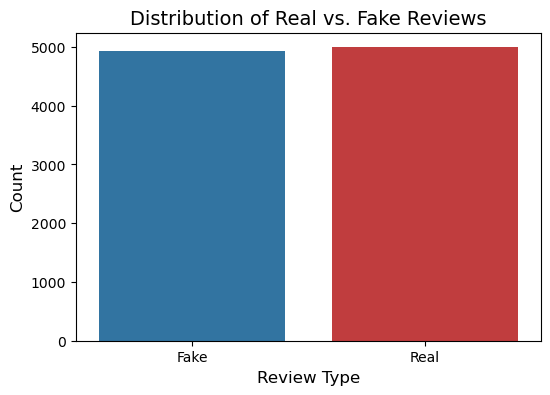

In [12]:
# A temporary dataframe created for EDA so we don't affect up the training data labels
eda_df = train_df.copy()
eda_df['Review_Type'] = eda_df['flagged'].map({0: 'Real', 1: 'Fake'})

plt.figure(figsize=(6, 4))
sns.countplot(data=eda_df, x='Review_Type', palette=['#1f77b4', '#d62728'])
plt.title('Distribution of Real vs. Fake Reviews', fontsize=14)
plt.xlabel('Review Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

# Review Length Distribution
Fake reviews often have strange length patterns. A boxplot is perfect here to show the median and the outliers.

/tmp/ipykernel_108/2579888489.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=eda_df, x='Review_Type', y='ReviewLength', palette=['#1f77b4', '#d62728'])


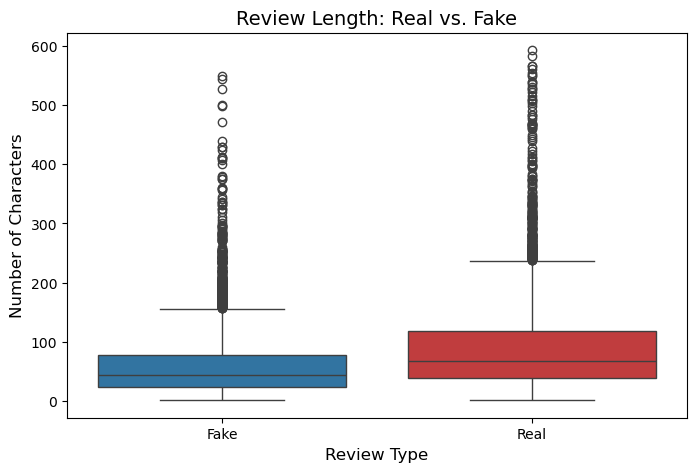

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=eda_df, x='Review_Type', y='ReviewLength', palette=['#1f77b4', '#d62728'])
plt.title('Review Length: Real vs. Fake', fontsize=14)
plt.xlabel('Review Type', fontsize=12)
plt.ylabel('Number of Characters', fontsize=12)

# Optional: If you have massive outliers that squash the boxplot, 
# you can limit the y-axis to make the boxes easier to see. 
# plt.ylim(0, 2000) 

plt.show()

# Star Rating Behavior (The Motivation)
This answers: Are fake reviews mostly 5-star or 1-star?

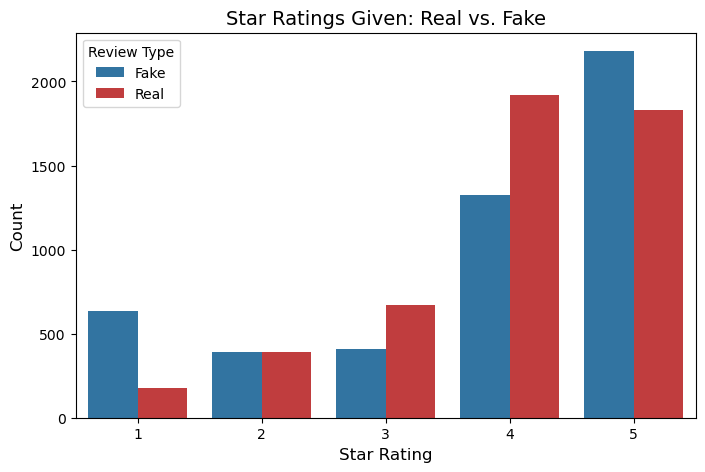

In [14]:
plt.figure(figsize=(8, 5))
sns.countplot(data=eda_df, x='rating', hue='Review_Type', palette=['#1f77b4', '#d62728'])
plt.title('Star Ratings Given: Real vs. Fake', fontsize=14)
plt.xlabel('Star Rating', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Review Type')
plt.show()

# Correlation Heatmap

This checks if numeric features (like how many friends a user has vs. how many reviews they've written) are correlated before text analysis.

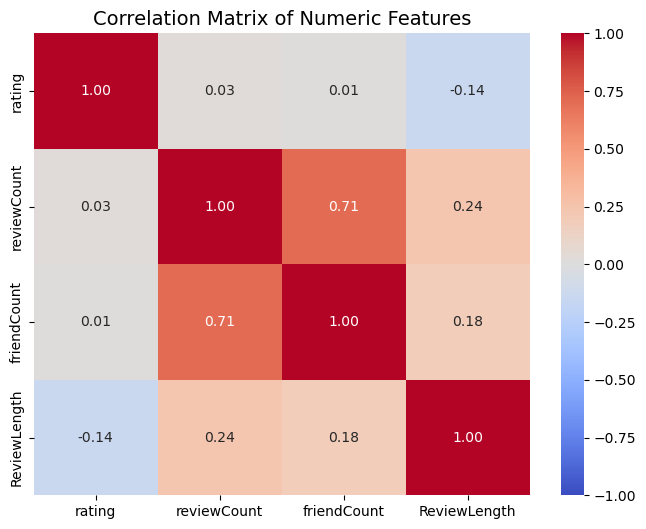

In [15]:
# Select only the numeric columns
numeric_cols = ['rating', 'reviewCount', 'friendCount', 'ReviewLength']

plt.figure(figsize=(8, 6))
# Calculate correlations and plot the heatmap
sns.heatmap(train_df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numeric Features', fontsize=14)
plt.show()

# Random Forest (ensuring code works)
!!!Training the Model (and testing on the training set just to check if it is working)!!!

In [2]:
x_train = train_df['reviewContent']
y_train = train_df['flagged']

print(x_train.head(), y_train.head())

# keeps 5000 frequently used words, removes ifs,thes,ands. ngram looks at single words and 2-word phrases
vectorizer = TfidfVectorizer(stop_words='english', max_features=3000, ngram_range=(1,2))
x_train_vectorized = vectorizer.fit_transform(x_train)

print(x_train_vectorized.shape)

model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(x_train_vectorized, y_train)

predictions = model_rf.predict(x_train_vectorized)

# literally just testing with what it learned
print(classification_report(y_train,predictions))

0    as new resident chicago los angeles i mission ...
1    great place rarely wait fairly easy find parki...
2    back bar makes feel though transported china s...
3    hands one favorite tourist restaurants city th...
4    service impeccable staff helpful owner works h...
Name: reviewContent, dtype: object 0    1
1    0
2    1
3    0
4    1
Name: flagged, dtype: int64
(9926, 3000)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4993
           1       1.00      1.00      1.00      4933

    accuracy                           1.00      9926
   macro avg       1.00      1.00      1.00      9926
weighted avg       1.00      1.00      1.00      9926



# Random Forest (Test Dataset)

In [3]:
test_df = pd.read_csv('new_data_test.csv', on_bad_lines='skip', sep='\t')
# print no. of rows
print(len(test_df))

test_df= test_df.dropna(subset=['reviewContent'])
# print new no. of rows to see how many NaN
print(len(test_df))

# no missing values

x_test = test_df['reviewContent']
y_test = test_df['flagged']

x_test_vectorized = vectorizer.transform(x_test)

test_predictions = model_rf.predict(x_test_vectorized)
print(classification_report(y_test, test_predictions))
print(accuracy_score(y_test,test_predictions))

2483
2483
              precision    recall  f1-score   support

           0       0.65      0.69      0.67      1212
           1       0.69      0.64      0.66      1271

    accuracy                           0.66      2483
   macro avg       0.67      0.67      0.66      2483
weighted avg       0.67      0.66      0.66      2483

0.6645187273459525


# Fine-Tune RandomForest with GridSearch
(doesnt perform well)

In [4]:
# defining the parameters of the grid
param_grid={
    'n_estimators' : [100, 200],
    'max_depth' : [None, 20] #some will grow infinitely, 20 branches
}

#sets up gridsearch. cv is crossvalidating, njobs is how fast
grid_search = GridSearchCV(model_rf, param_grid, cv=3, scoring='f1', n_jobs=-1)

#train
grid_search.fit(x_train_vectorized, y_train)

#pick the best model

best_rf = grid_search.best_estimator_
print(f"Best Knobs were:{grid_search.best_params_}")

# predict and grade

rf_predictions = best_rf.predict(x_test_vectorized)
print(f"tuned random forest accuracy: {accuracy_score(y_test, rf_predictions)}")
print(f"tuned random forest f1 score: {f1_score(y_test,rf_predictions)}")
      
      



Best Knobs were:{'max_depth': 20, 'n_estimators': 200}
tuned random forest accuracy: 0.6612968183648812
tuned random forest f1 score: 0.6746615087040619


# Basic Logistic Regression
also performs poorly

In [5]:
model_log = LogisticRegression(max_iter=1000, random_state=42)
model_log.fit(x_train_vectorized, y_train)
log_predictions = model_log.predict(x_test_vectorized)

print(f"tuned LogReg accuracy: {accuracy_score(y_test, log_predictions)}")
print(f"tuned LogReg f1 score: {f1_score(y_test,log_predictions)}")

tuned LogReg accuracy: 0.6810310108739428
tuned LogReg f1 score: 0.6891679748822606


# Sentiment Analysis
Use the imported TextBlob. Create a new sentiment_score column to convert the reviewContent into a score between -1 to 1

In [6]:
#function that reads the review and calculates the vibe from -1 to 1. Calling this Sentiment Score

def get_sentiment(text):
    #wrap the text into a simple stirng for ease
    return TextBlob(str(text)).sentiment.polarity

#making a new column and applying to train set
train_df['Sentiment_Score'] = train_df['reviewContent'].apply(get_sentiment)

#making a new column and applying to test set
test_df['Sentiment_Score'] = test_df['reviewContent'].apply(get_sentiment)

#results to check how each row/review scored
# print(train_df[['reviewContent', 'flagged', 'Sentiment_Score']].head(10))
# print(test_df[['reviewContent', 'flagged', 'Sentiment_Score']].head(10))

# Enhanced Logistic Regression Model
Using Vectorized review & numerical columns trained a brand new logisitc regression model


In [7]:
#  Grab the numeric columns + your new Sentiment Score
num_cols = ['rating', 'reviewCount', 'friendCount', 'ReviewLength', 'Sentiment_Score']
num_features_train = train_df[num_cols]
num_features_test = test_df[num_cols]

# Scale the numbers so they are mathematically balanced
scaler = StandardScaler()
num_features_train_scaled = scaler.fit_transform(num_features_train)
num_features_test_scaled = scaler.transform(num_features_test) # Only transform the test data!

#  Glue the TF-IDF text matrix and the scaled numbers together
x_train_final = hstack((x_train_vectorized, num_features_train_scaled))
x_test_final = hstack((x_test_vectorized, num_features_test_scaled))

# Train a brand new Logistic Regression model on the combined data
model_ultimate = LogisticRegression(max_iter=1000, random_state=42)
model_ultimate.fit(x_train_final, y_train)

#  Make predictions
final_predictions = model_ultimate.predict(x_test_final)

print(f"Old Text-Only F1 Score: 0.689")
print(f"NEW Combined(text + sentiment) Accuracy:  {accuracy_score(y_test, final_predictions):.3f}")
print(f"NEW Combined(text + sentiment) F1 Score:  {f1_score(y_test, final_predictions):.3f}")
print(classification_report(y_test, final_predictions))

Old Text-Only F1 Score: 0.689
NEW Combined(text + sentiment) Accuracy:  0.828
NEW Combined(text + sentiment) F1 Score:  0.845
              precision    recall  f1-score   support

           0       0.89      0.74      0.81      1212
           1       0.79      0.91      0.85      1271

    accuracy                           0.83      2483
   macro avg       0.84      0.83      0.83      2483
weighted avg       0.84      0.83      0.83      2483



# Enhanced Random Forest Model

In [17]:
# Train a new more powerful Random Forest on the combined data
# n_estimators=200 means we are building 200 trees to vote on the answer
model_ultimate = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
model_ultimate.fit(x_train_final, y_train)

# Make predictions
final_predictions = model_ultimate.predict(x_test_final)

print(f"Combined Accuracy:  {accuracy_score(y_test, final_predictions):.3f}")
print(f"Combined F1 Score (Binary):  {f1_score(y_test, final_predictions):.3f}")

print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, final_predictions))

Combined Accuracy:  0.847
Combined F1 Score (Binary):  0.853

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1212
           1       0.84      0.87      0.85      1271

    accuracy                           0.85      2483
   macro avg       0.85      0.85      0.85      2483
weighted avg       0.85      0.85      0.85      2483



# Top words indicating FAKE reviews

In [9]:
# the list of the 3,000 words vectorizer kept
words = vectorizer.get_feature_names_out()

# mathematical weights the Logistic Regression model learned
weights = model_log.coef_[0]

# Mash them together into a Pandas DataFrame so it looks nice
importance_df = pd.DataFrame({'Word': words, 'Weight': weights})

# 4. Sort them to see the extremes
most_fake_words = importance_df.sort_values(by='Weight').head(10)
most_real_words = importance_df.sort_values(by='Weight', ascending=False).head(10)

print("Top 10 Words Indicating a FAKE Review:")
print(most_fake_words)

print("Top 10 Words Indicating a REAL Review:")
print(most_real_words)

Top 10 Words Indicating a FAKE Review:
            Word    Weight
84        alinea -4.115599
896      falafel -3.177223
2018        pork -2.544271
2806  vegetarian -2.321275
2803       vegan -2.319648
1389       irazu -2.150991
2076    publican -2.124821
2358       shake -1.932024
2787          ve -1.802401
650         damn -1.769120
Top 10 Words Indicating a REAL Review:
            Word    Weight
1857       owner  3.085998
2389      simply  2.600324
1609     manager  2.064889
232         best  1.992810
509        coast  1.786383
2638    terrible  1.774535
2816  vietnamese  1.768061
2691        told  1.715858
2850    waitress  1.619134
1737        nana  1.603450


# Real vs. Fake Review: Sentiment Distribution

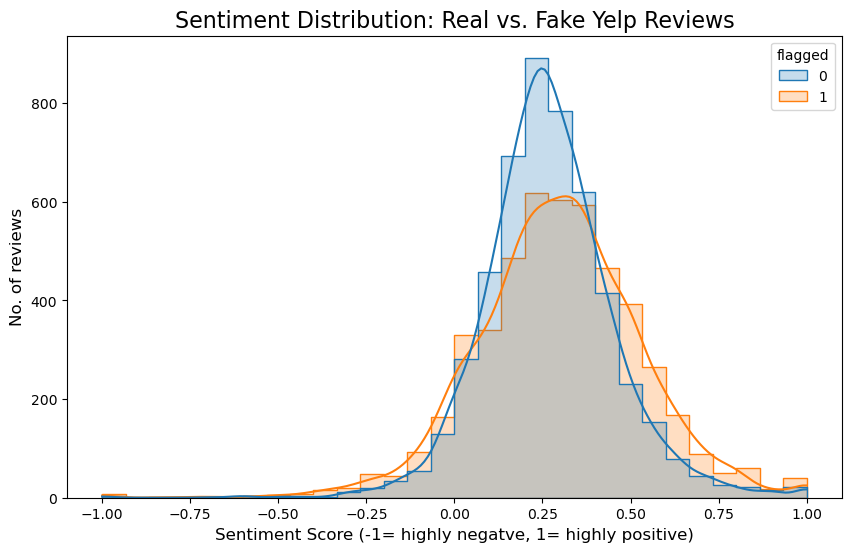

In [10]:
plt.figure(figsize=(10,6))

sns.histplot(data=train_df,
           x='Sentiment_Score',
           hue='flagged',
           kde=True, #makes it smooth
           element='step', #makes it look clean
           bins=30) 

plt.title('Sentiment Distribution: Real vs. Fake Yelp Reviews', fontsize=16)
plt.xlabel('Sentiment Score (-1= highly negatve, 1= highly positive)', fontsize=12)
plt.ylabel('No. of reviews', fontsize=12)

plt.show()

# Feature Importance Chart 
What does the model look at first when it has to decide between fake and real

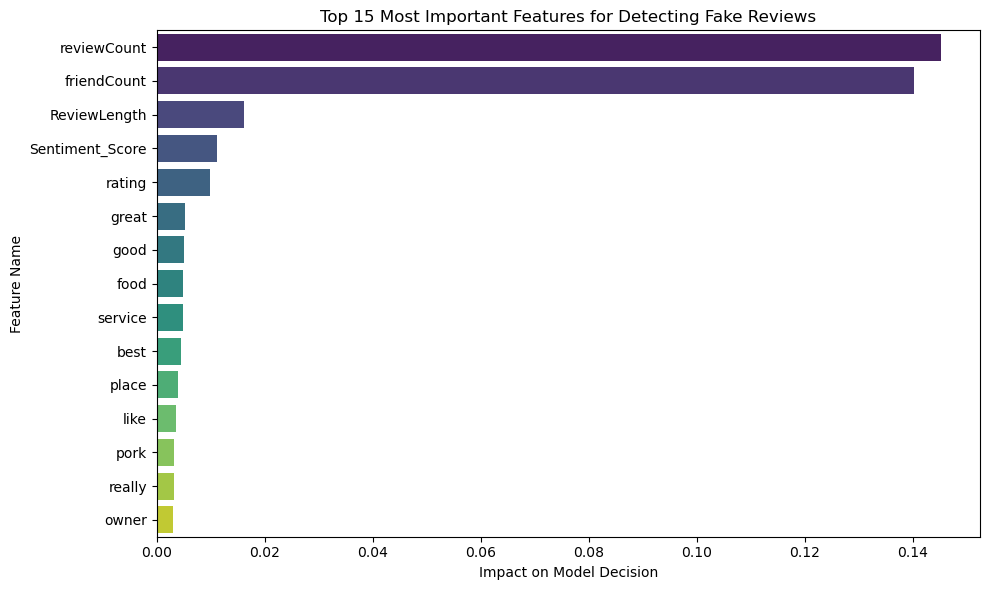

In [11]:
# Get the names of all your features
# Get the text words
text_feature_names = vectorizer.get_feature_names_out()
# Combine them with your numeric column names
all_feature_names = np.concatenate([text_feature_names, num_cols])

# Extract the importance scores from the Random Forest
importances = model_ultimate.feature_importances_

# Create a DataFrame to sort them
feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
})

# Sort by most important
top_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(15)

# Visualize
plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Top 15 Most Important Features for Detecting Fake Reviews')
plt.xlabel('Impact on Model Decision')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

# Conclusion & Insights

## Conclusion & Business Insights

### 1. Technical Performance Summary
Our objective was to build a robust machine learning pipeline capable of differentiating between genuine and deceptive Yelp reviews. After testing multiple algorithms, our **Enhanced Random Forest model** emerged as the strongest predictive engine, achieving an **84.7% Accuracy** and an **85.3% F1 Score**. By combining TF-IDF text vectorization with numeric metadata and sentiment analysis, the model successfully captured the complex, non-linear patterns that define deceptive behavior.

### 2. Behavioral & Human-Centered Insights
While the Random Forest provided the highest accuracy, analyzing the weights from our Logistic Regression model offered crucial transparency into *how* deceptive language operates. 
* **The Anatomy of a Real Review:** Genuine customers prioritize human connection and service. The highest weighted words for real reviews included relational terms like *owner*, *manager*, *waitress*, and *told*. 
* **The Anatomy of a Fake Review:** Deceptive reviews often lack this human element, over-indexing on specific items or extreme hyperbole to manipulate the algorithm rather than share an experience.
* **Emotional Extremes:** Our Exploratory Data Analysis revealed that fake reviews polarize at the extremes (1-star or 5-star, highly negative or highly positive sentiment). Malicious actors do not leave nuanced 3-star reviews; their goal is immediate manipulation of a business's reputation.

### 3. Strategic Business Recommendations
Implementing this model in a real-world business context requires balancing platform integrity with user trust.

* **Deploy as a Human-in-the-Loop Filter:** Given the nuance of human language, a 100% automated deletion system risks silencing genuine customers. The model should be deployed as an initial filter, automatically separating reviews that cross a specific probability threshold for manual human review.
* **Prioritize False Positives over False Negatives:** For a platform like Yelp, brand reputation is paramount. Falsely accusing a genuine customer of leaving a fake review (False Positive) is far more damaging to user trust than letting a few deceptive reviews slip through (False Negative). The model's classification threshold should be tuned conservatively to protect authentic voices. Precision score using Random Forest was better thus reducing False Positives more.
* **Monitor Sentiment Velocity:** Businesses should use sentiment tracking as an early warning system. A sudden influx of highly polarized, extreme-sentiment reviews over a short period is a strong indicator of a coordinated bot attack or paid review campaign, allowing moderators to act proactively.